In [18]:
# Import all libraries and dependencies
import pandas as pd

In [19]:
import pandas as pd

# Load the CSV
df = pd.read_csv("BankChurners.csv")

# Drop the 'CLIENTNUM' column
df.drop(columns=['CLIENTNUM'], inplace=True)
df.drop(columns=['Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1'], inplace=True)
df.drop(columns=['Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'], inplace=True)

# Select numeric and categorical columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Print unique values for each categorical column
for col in categorical_cols:
    print(f"Unique values in '{col}':")
    print(df[col].unique())
    print("-" * 50)

Unique values in 'Attrition_Flag':
['Existing Customer' 'Attrited Customer']
--------------------------------------------------
Unique values in 'Gender':
['M' 'F']
--------------------------------------------------
Unique values in 'Education_Level':
['High School' 'Graduate' 'Uneducated' 'Unknown' 'College' 'Post-Graduate'
 'Doctorate']
--------------------------------------------------
Unique values in 'Marital_Status':
['Married' 'Single' 'Unknown' 'Divorced']
--------------------------------------------------
Unique values in 'Income_Category':
['$60K - $80K' 'Less than $40K' '$80K - $120K' '$40K - $60K' '$120K +'
 'Unknown']
--------------------------------------------------
Unique values in 'Card_Category':
['Blue' 'Gold' 'Silver' 'Platinum']
--------------------------------------------------


In [20]:
cleaned_df = df.copy()
# Drop NA
cleaned_df.dropna()
# Drop duplicates
cleaned_df.drop_duplicates(inplace=True)

# IQR Filtering
for col in numeric_cols:
    Q1 = cleaned_df[col].quantile(0.25)
    Q3 = cleaned_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    IQR_cleaned_df = cleaned_df[(cleaned_df[col] >= lower_bound) & (cleaned_df[col] <= upper_bound)]

# Step 4: Check final shape after removing outliers
print("Cleaned dataset shape:", cleaned_df.shape)

# Optional: Save cleaned data
cleaned_df.to_csv("IQRcleaned_dataset.csv", index=False)
cleaned_df.head

Cleaned dataset shape: (10127, 20)


<bound method NDFrame.head of           Attrition_Flag  Customer_Age Gender  Dependent_count  \
0      Existing Customer            45      M                3   
1      Existing Customer            49      F                5   
2      Existing Customer            51      M                3   
3      Existing Customer            40      F                4   
4      Existing Customer            40      M                3   
...                  ...           ...    ...              ...   
10122  Existing Customer            50      M                2   
10123  Attrited Customer            41      M                2   
10124  Attrited Customer            44      F                1   
10125  Attrited Customer            30      M                2   
10126  Attrited Customer            43      F                2   

      Education_Level Marital_Status Income_Category Card_Category  \
0         High School        Married     $60K - $80K          Blue   
1            Graduate         Single 

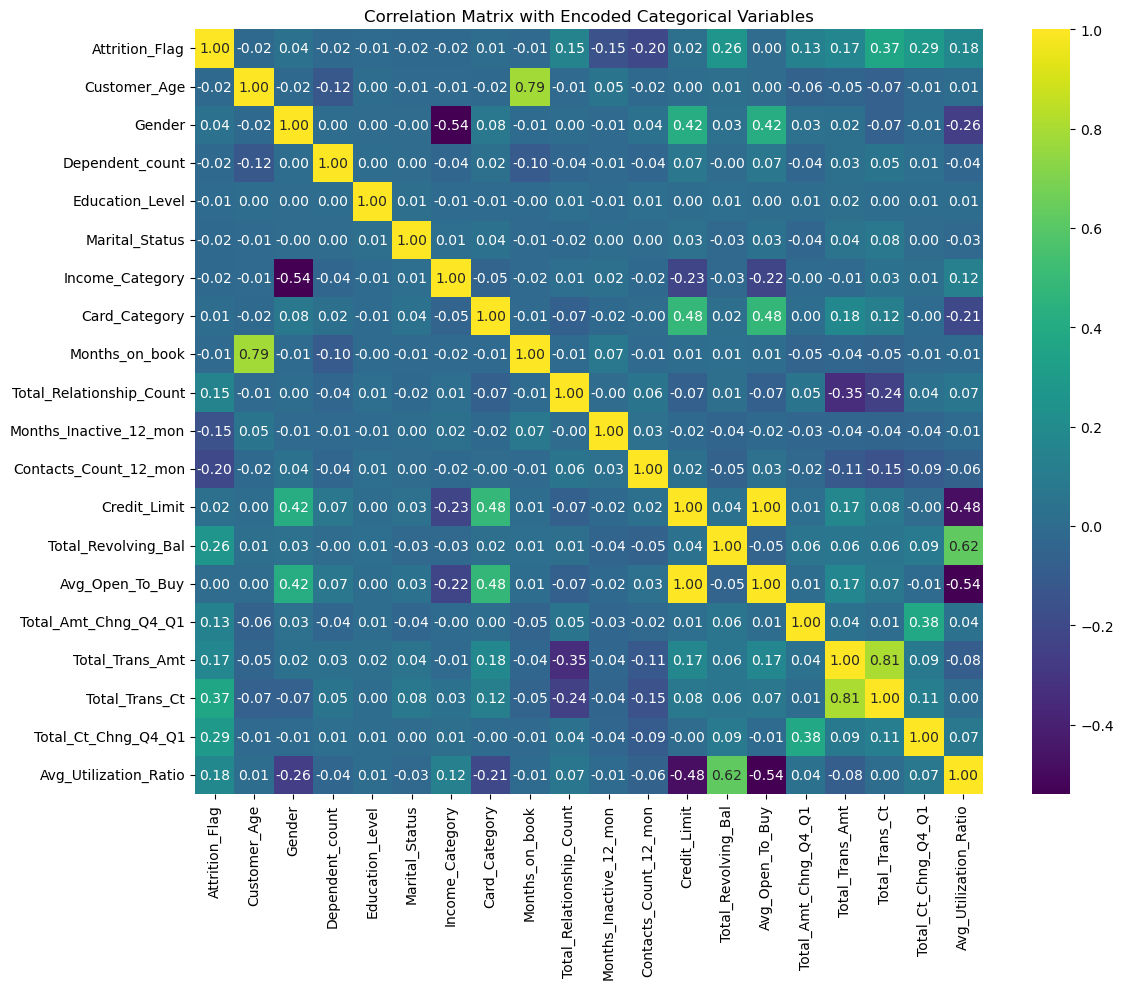

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# List of categorical columns as provided.
categorical_cols = [
    'Attrition_Flag', 
    'Gender', 
    'Education_Level', 
    'Marital_Status', 
    'Income_Category', 
    'Card_Category'
]

# Create a copy of the DataFrame for encoding.
df_encoded = cleaned_df.copy()

# Apply label encoding to each categorical column.
le = LabelEncoder()
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Compute the correlation matrix for the entire DataFrame.
corr_matrix = df_encoded.corr()

# Create a heatmap for the correlation matrix.
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='viridis', annot=True, fmt=".2f")
plt.title('Correlation Matrix with Encoded Categorical Variables')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


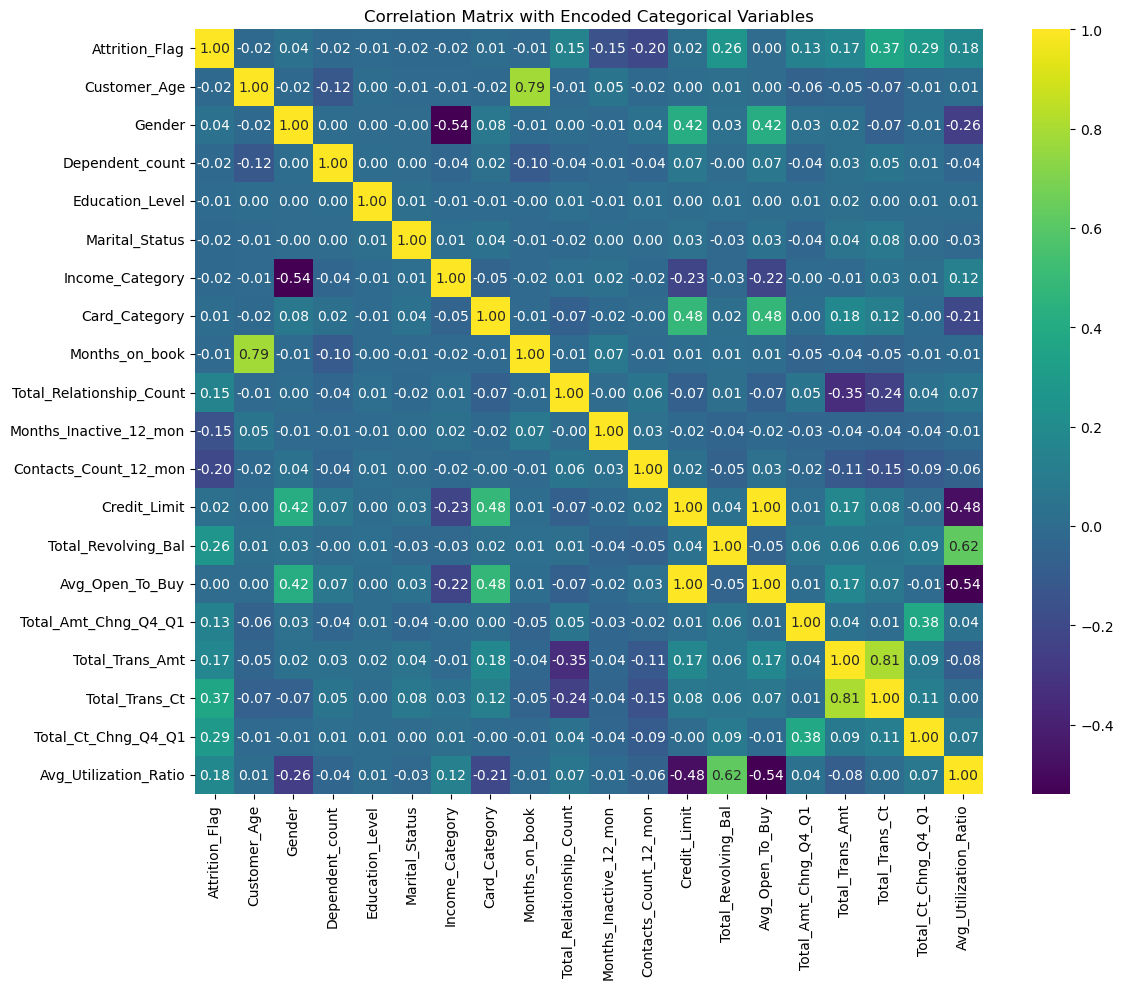

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# List of categorical columns as provided.
categorical_cols = [
    'Attrition_Flag', 
    'Gender', 
    'Education_Level', 
    'Marital_Status', 
    'Income_Category', 
    'Card_Category'
]

# Create a copy of the DataFrame for encoding.
df_encoded = IQR_cleaned_df.copy()

# Apply label encoding to each categorical column.
le = LabelEncoder()
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Compute the correlation matrix for the entire DataFrame.
corr_matrix = df_encoded.corr()

# Create a heatmap for the correlation matrix.
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='viridis', annot=True, fmt=".2f")
plt.title('Correlation Matrix with Encoded Categorical Variables')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [23]:
import pandas as pd
from sklearn.feature_selection import f_classif

# Assume df_encoded is your DataFrame with all features encoded, including "Attrition_Flag".
# Define the target variable.
target = 'Attrition_Flag'

# Create X containing all features except the target variable,
# and y containing the target.
X = df_encoded.drop(columns=[target])
y = df_encoded[target]

# Compute F-scores and p-values using the ANOVA F-test.
F_values, p_values = f_classif(X, y)

# Create a DataFrame to display the F-scores and p-values along with the feature names.
f_scores_df = pd.DataFrame({
    'Feature': X.columns,
    'F_score': F_values,
    'p_value': p_values
}).sort_values(by='F_score', ascending=False)

print("F-scores against Attrition_Flag:")
print(f_scores_df)


F-scores against Attrition_Flag:
                     Feature      F_score        p_value
16            Total_Trans_Ct  1620.121692   0.000000e+00
17       Total_Ct_Chng_Q4_Q1   930.078416  1.647725e-195
12       Total_Revolving_Bal   752.702408  6.630148e-160
10     Contacts_Count_12_mon   441.868050   4.697490e-96
18     Avg_Utilization_Ratio   332.876795   3.357689e-73
15           Total_Trans_Amt   296.227714   1.857439e-65
9     Months_Inactive_12_mon   240.910376   1.032664e-53
8   Total_Relationship_Count   233.072886   4.829281e-52
14      Total_Amt_Chng_Q4_Q1   176.961638   4.836643e-40
1                     Gender    14.085007   1.757076e-04
11              Credit_Limit     5.773729   1.628536e-02
2            Dependent_count     3.652825   5.600239e-02
4             Marital_Status     3.503085   6.128344e-02
0               Customer_Age     3.356074   6.698689e-02
5            Income_Category     3.131546   7.682098e-02
7             Months_on_book     1.897071   1.684370e-0

In [24]:
import pandas as pd
from sklearn.feature_selection import mutual_info_classif

# Assume df_encoded is your DataFrame with features encoded, including "Attrition_Flag".

# Define the target variable and feature set.
target = 'Attrition_Flag'
X = df_encoded.drop(columns=[target])
y = df_encoded[target]

# Compute the mutual information for each feature with respect to the target.
mi_values = mutual_info_classif(X, y, random_state=42)

# Create a DataFrame to display the mutual information values along with the feature names.
mi_df = pd.DataFrame({
    'Feature': X.columns,
    'Mutual_Information': mi_values
}).sort_values(by='Mutual_Information', ascending=False)

print("Mutual Information of each feature with Attrition_Flag:")
print(mi_df)


Mutual Information of each feature with Attrition_Flag:
                     Feature  Mutual_Information
15           Total_Trans_Amt            0.159579
16            Total_Trans_Ct            0.113819
17       Total_Ct_Chng_Q4_Q1            0.097490
12       Total_Revolving_Bal            0.081312
18     Avg_Utilization_Ratio            0.046084
14      Total_Amt_Chng_Q4_Q1            0.028307
10     Contacts_Count_12_mon            0.023935
13           Avg_Open_To_Buy            0.020645
9     Months_Inactive_12_mon            0.017864
8   Total_Relationship_Count            0.013571
11              Credit_Limit            0.009097
3            Education_Level            0.006701
7             Months_on_book            0.005862
4             Marital_Status            0.005622
2            Dependent_count            0.005081
0               Customer_Age            0.002752
1                     Gender            0.002016
6              Card_Category            0.001135
5            